## NBA FAS ASSESSMENT

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.metrics import root_mean_squared_error, accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve


# !pip install nba_api pandas numpy requests tqdm -- Download team dataset from NBA website
#from tqdm import tqdm
#from nba_api.stats.endpoints import leaguedashplayerstats, leaguestandingsv3



### Query Datasets

In [2]:
# --- Player-level files ---
per_game    = pd.read_csv("Player Per Game.csv")
advanced    = pd.read_csv("Advanced.csv")
totals      = pd.read_csv("Player Totals.csv")
award       = pd.read_csv("Player Award Shares.csv")
all_star    = pd.read_csv("All-Star Selections.csv")

# --- Team-level files ---
team_totals = pd.read_csv("Team Totals.csv")
team_pg     = pd.read_csv("Team Stats Per Game.csv")
team_abbrev = pd.read_csv("Team Abbrev.csv")   # used to map full team names to abbreviations

print("Loaded all CSVs.")


Loaded all CSVs.


### Data Processing

#### Filter to NBA seasons 2000–2026

In [3]:
# Player tables

def filter_player(df):
    return df[(df["lg"] == "NBA") & (df["season"].between(2000, 2026))]

per_game_f = filter_player(per_game)
advanced_f = filter_player(advanced)
totals_f   = filter_player(totals)

# Awards and All-Star have no lg column
award_f    = award[award["season"].between(2000, 2026)]
all_star_f = all_star[all_star["season"].between(2000, 2026)]

# Team tables: NBA, regular season, no League Average
def filter_team(df):
    return df[
        (df["lg"] == "NBA") &
        (df["season"].between(2000, 2026)) &
        (df["playoffs"] == False) &
        (df["team"] != "League Average")
    ]

team_totals_f = filter_team(team_totals)
team_pg_f     = filter_team(team_pg)

print("After filtering to NBA 2000–2026:")
print("\nPer Game:", per_game_f.shape)
print("\nAdvanced:", advanced_f.shape)
print("\nTotals:", totals_f.shape)
print("\nTeam Totals:", team_totals_f.shape)
print("\nTeam Per Game:", team_pg_f.shape)


After filtering to NBA 2000–2026:

Per Game: (16321, 32)

Advanced: (16321, 30)

Totals: (16321, 33)

Team Totals: (385, 28)

Team Per Game: (385, 28)


#### Removes multi-team rows (2TM, 3TM, 4TM, 5TM)

In [4]:
# These are NOT real teams names and should not be used in modeling.

incorrect_teams = ["2TM", "3TM", "4TM", "5TM"]

per_game_f = per_game_f[~per_game_f["team"].isin(incorrect_teams)]
advanced_f = advanced_f[~advanced_f["team"].isin(incorrect_teams)]
totals_f   = totals_f[~totals_f["team"].isin(incorrect_teams)]

print("After dropping 2TM/3TM/4TM/5TM:")
print("\nPer Game:", per_game_f.shape)
print("\nAdvanced:", advanced_f.shape)
print("\nTotals:", totals_f.shape)

After dropping 2TM/3TM/4TM/5TM:

Per Game: (14760, 32)

Advanced: (14760, 30)

Totals: (14760, 33)


#### Build the player table (Per Game, Advanced and Totals)

In [5]:
# Join on the common stable keys:
# season, lg, player, player_id, age, team, pos


# Merge Per_game and advance, Per_game and totals_f
player = per_game_f.merge(
    advanced_f,
    on=["season", "lg", "player", "player_id", "age", "team", "pos"],
    how="left", # I want to keep per_game dataset as my base data
    suffixes=("_pg", "_adv")
)
print("After merging Advanced onto Per Game:", player.shape)

player = player.merge(
    totals_f,
    on=["season", "lg", "player", "player_id", "age", "team", "pos"],
    how="left",
    suffixes=("", "_tot")
)
print("After merging Totals:", player.shape)


After merging Advanced onto Per Game: (14760, 55)
After merging Totals: (14760, 81)


#### Add MVP award info (target labels)

In [6]:
# Filter to MVP only
mvp_award = award_f[award_f["award"] == "nba mvp"].copy()
mvp_award = mvp_award[
    ["season", "player", "player_id", "first", "pts_won", "pts_max", "share", "winner"]
]

player = player.merge(
    mvp_award,
    on=["season", "player", "player_id"],
    how="left"
)

# Players who never received votes have NaN treat as zero
player["share"]  = player["share"].fillna(0)
player["winner"] = player["winner"].fillna(False)  # still boolean for now

print("\nAfter merging MVP awards:", player.shape)
print("Non-zero MVP share rows:", (player["share"] > 0).sum())



After merging MVP awards: (14760, 86)
Non-zero MVP share rows: 353


/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_19096/284895113.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  player["winner"] = player["winner"].fillna(False)  # still boolean for now


#### Add All-Star flag

In [7]:
# One row per player-season in All-Star file
all_star_flag = all_star_f[["season", "player", "player_id"]].drop_duplicates()
all_star_flag["is_all_star"] = 1

player = player.merge(
    all_star_flag,
    on=["season", "player", "player_id"],
    how="left"
)

# Non All-Stars get 0
player["is_all_star"] = player["is_all_star"].fillna(0).astype(int)

print("After merging All-Star flag:", player.shape)
print("All-Star seasons:", player["is_all_star"].sum())


After merging All-Star flag: (14760, 87)
All-Star seasons: 666


#### Build team table (Team Totals and Team Per Game)

In [8]:
# team_abbrev has columns like: season, lg, team, abbreviation, playoffs
# Build a mapping from full team name to abbreviation.


team_map = dict(zip(team_abbrev["team"], team_abbrev["abbreviation"]))

# Convert full team names to abbreviations for both team tables
team_totals_f["team"] = team_totals_f["team"].map(team_map)
team_pg_f["team"]     = team_pg_f["team"].map(team_map)

team_pg_f = team_pg[
    (team_pg["lg"] == "NBA") &
    (team_pg["season"].between(2000, 2025)) &
    (team_pg["playoffs"] == False)
].copy()

team_pg_f = team_pg_f.rename(columns={
    "mp_per_game":   "mp_per_game_y",
    "fg_per_game":   "fg_per_game_y",
    "fga_per_game":  "fga_per_game_y",
    "fg_percent":    "fg_percent_pg",
    "x3p_per_game":  "x3p_per_game_y",
    "x3pa_per_game": "x3pa_per_game_y",
    "x3p_percent":   "x3p_percent_pg",
    "x2p_per_game":  "x2p_per_game_y",
    "x2pa_per_game": "x2pa_per_game_y",
    "x2p_percent":   "x2p_percent_pg",
    "ft_per_game":   "ft_per_game_y",
    "fta_per_game":  "fta_per_game_y",
    "ft_percent":    "ft_percent_pg",
    "orb_per_game":  "orb_per_game_y",
    "drb_per_game":  "drb_per_game_y",
    "trb_per_game":  "trb_per_game_y",
    "ast_per_game":  "ast_per_game_y",
    "stl_per_game":  "stl_per_game_y",
    "blk_per_game":  "blk_per_game_y",
    "tov_per_game":  "tov_per_game_y",
    "pf_per_game":   "pf_per_game_y",
    "pts_per_game":  "pts_per_game_y",
})

print("\nTeam per-game table shape:", team_pg_f.shape)


print("\nUnique team values in team_totals_f after mapping:")
print(team_totals_f["team"].dropna().unique()[:20])


# Merge team totals and team per-game into one team table
teams = team_totals_f.merge(
    team_pg_f,
    on=["season", "lg", "team", "playoffs", "g"],
    how="inner",
    suffixes=("_tot", "_tm")  # _tm = team per-game stats
)

print("\nTeams table shape (after merging totals + per-game):", teams.shape)
print("Example team columns:", [c for c in teams.columns if "per_game" in c or "percent" in c][:15])



Team per-game table shape: (381, 28)

Unique team values in team_totals_f after mapping:
['ATL' 'BOS' 'BRK' 'CHI' 'CHH' 'CLE' 'DAL' 'DNN' 'DET' 'GSW' 'HOU' 'INA'
 'LAC' 'LAL' 'MEM' 'MIA' 'MIL' 'MIN' 'NOP' 'NYK']

Teams table shape (after merging totals + per-game): (0, 51)
Example team columns: ['fg_percent', 'x3p_percent', 'x2p_percent', 'ft_percent', 'mp_per_game_y', 'fg_per_game_y', 'fga_per_game_y', 'fg_percent_pg', 'x3p_per_game_y', 'x3pa_per_game_y', 'x3p_percent_pg', 'x2p_per_game_y', 'x2pa_per_game_y', 'x2p_percent_pg', 'ft_per_game_y']


/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_19096/3544628919.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  team_totals_f["team"] = team_totals_f["team"].map(team_map)
/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_19096/3544628919.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  team_pg_f["team"]     = team_pg_f["team"].map(team_map)


#### Merge team stats into player table using team abbreviations

In [9]:
# NOTE:
# - player['team'] is already an abbreviation (LAL, DEN, etc.)
# - team_pg_f['abbreviation'] is the same code
# So we merge on season, lg, and player.team == team_pg_f.abbreviation

master = player.merge(
    team_pg_f,
    left_on=["season", "lg", "team"],
    right_on=["season", "lg", "abbreviation"],
    how="left"
)

print("\nFinal master shape:", master.shape)

# Check how many are still missing in a couple of team columns
for col in ["mp_per_game_y", "pts_per_game_y", "fg_percent_pg"]:
    na_pct = master[col].isna().mean() * 100
    print(f"{col}: {na_pct:.1f}% missing (this is due to incomplete Kaggle team data)")



Final master shape: (14760, 113)
mp_per_game_y: 53.9% missing (this is due to incomplete Kaggle team data)
pts_per_game_y: 53.9% missing (this is due to incomplete Kaggle team data)
fg_percent_pg: 53.9% missing (this is due to incomplete Kaggle team data)


#### Save fixed master dataset for modeling

In [10]:
master.to_csv("nba_mvp_master_fixed.csv", index=False)
print("\nSaved fixed merged dataset as: nba_mvp_master_fixed.csv")


Saved fixed merged dataset as: nba_mvp_master_fixed.csv


### Data tranformation on merged dataset

#### Load master dataset

In [11]:
# This is the file I created after merging all the datasets

# master = pd.read_csv("nba_mvp_master_fixed.csv")

print("Original dataset shape:", master.shape)
print("Number of original columns:", len(master.columns))


Original dataset shape: (14760, 113)
Number of original columns: 113


In [12]:
master.columns

Index(['season', 'lg', 'player', 'player_id', 'age', 'team_x', 'pos', 'g_pg',
       'gs_pg', 'mp_per_game',
       ...
       'ft_percent_pg', 'orb_per_game_y', 'drb_per_game_y', 'trb_per_game_y',
       'ast_per_game_y', 'stl_per_game_y', 'blk_per_game_y', 'tov_per_game_y',
       'pf_per_game_y', 'pts_per_game_y'],
      dtype='object', length=113)

#### Select the columns to keep for MVP modeling

In [13]:
# I grouped these columns into categories to stay organized.
# This makes it easier to understand what each group is used for.

# Identification columns (these help us know who the player is)
id_cols = [
    "season",       # season (e.g., 2024 = 2023-24 season)
    "lg",           # league (NBA)
    "player",       # player name
    "player_id",    # unique player identifier
    "age",          # age in that season
    "team_x",       # team code (this is the player team column)
    "pos"           # position
]

# Target columns (the values we are trying to predict during training)
target_cols = [
    "winner",       # 1 if MVP winner, 0 otherwise
    "is_all_star"   # 1 if All-Star that season, 0 otherwise
]

# Important per-game stats (basic production)
per_game_cols = [
    "g_x",               # games played (from per-game table)
    "mp_per_game",       # minutes per game
    "pts_per_game",      # points per game
    "trb_per_game",      # total rebounds per game
    "ast_per_game",      # assists per game
    "stl_per_game",      # steals per game
    "blk_per_game",      # blocks per game
    "tov_per_game",      # turnovers per game
    "fg_percent",        # FG%
    "x3p_percent",       # 3P%
    "x2p_percent",       # 2P%
    "ft_percent"         # FT%
]

# Advanced statistics (these are very strong MVP predictors)
adv_cols = [
    "per",               # Player Efficiency Rating
    "ts_percent",        # True Shooting %
    "e_fg_percent",      # Effective FG %
    "x3p_ar",            # 3-point attempt rate
    "f_tr",              # Free throw rate
    "orb_percent",       # Offensive rebound %
    "drb_percent",       # Defensive rebound %
    "trb_percent",       # Total rebound %
    "ast_percent",       # Assist %
    "stl_percent",       # Steal %
    "blk_percent",       # Block %
    "tov_percent",       # Turnover %
    "usg_percent",       # Usage rate
    "ows",               # Offensive Win Shares
    "dws",               # Defensive Win Shares
    "ws",                # Win Shares
    "ws_48",             # Win Shares per 48 minutes
    "obpm",              # Offensive Box Plus/Minus
    "dbpm",              # Defensive Box Plus/Minus
    "bpm",               # Box Plus/Minus
    "vorp"               # Value Over Replacement Player
]

# Putting all the selected columns together
selected_columns = (
    id_cols
    + target_cols
    + per_game_cols
    + adv_cols
)

print("Total selected columns:", len(selected_columns))


Total selected columns: 42


#### Keep only the selected columns

In [14]:
# Some columns might not appear due to merging differences.
# So check and only keep columns that exist in the dataset.

existing_columns = [col for col in selected_columns if col in master.columns]


print("Columns kept:", len(existing_columns))


# Create the cleaned dataframe using only the existing useful columns
clean_master = master[existing_columns].copy()

print("Cleaned dataset shape:", clean_master.shape)


Columns kept: 42
Cleaned dataset shape: (14760, 42)


In [15]:
# View cleaned dataset

clean_master

,season,lg,player,player_id,age,team_x,pos,winner,is_all_star,g_x,...,tov_percent,usg_percent,ows,dws,ws,ws_48,obpm,dbpm,bpm,vorp
0,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,False,0,4,...,22.8,11.3,0.4,0.1,0.5,0.231,2.9,-1.4,1.5,0.1
1,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,False,0,5,...,12.1,28.0,0.1,0.3,0.4,0.102,-0.1,-0.5,-0.7,0.1
2,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,False,0,6,...,8.2,11.4,0.0,0.1,0.0,0.019,-5.3,0.0,-5.2,-0.1
3,2026,NBA,Santi Aldama,aldamsa01,25.0,MEM,PF,False,0,6,...,11.0,20.7,-0.1,0.2,0.1,0.047,-1.0,0.2,-0.8,0.0
4,2026,NBA,Nickeil Alexander-Walker,alexani01,27.0,ATL,SG,False,0,6,...,7.9,23.5,0.1,0.2,0.3,0.072,0.2,-0.6,-0.4,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14755,2000,NBA,David Wingate,wingada01,36.0,NYK,SG,False,0,7,...,18.2,16.3,-0.2,0.0,-0.1,-0.209,-12.3,0.7,-11.6,-0.1
14756,2000,NBA,Haywoode Workman,workmha01,34.0,MIL,PG,False,0,23,...,17.1,14.7,0.2,0.1,0.3,0.053,-1.1,-1.3,-2.4,0.0
14757,2000,NBA,Haywoode Workman,workmha01,34.0,TOR,PG,False,0,13,...,12.2,14.3,-0.1,0.1,0.0,0.023,-5.6,2.6,-2.9,0.0
14758,2000,NBA,Lorenzen Wright,wrighlo02,24.0,ATL,C,False,0,75,...,13.6,17.9,1.3,0.9,2.2,0.088,-2.5,-0.9,-3.5,-0.4


### Load the new team dataset from NBA website

In [16]:
""" def get_team_standings(start_year=2000, end_year=2024):
    dfs = []

    for year in range(start_year, end_year + 1):
        season_str = f"{year}-{str(year+1)[-2:]}"
        print("Fetching:", season_str)

        time.sleep(3)  # <-- IMPORTANT (prevents NBA API blocking)

        try:
            data = leaguestandingsv3.LeagueStandingsV3(
                season=season_str,
                timeout=60   # extend timeout
            ).get_data_frames()[0]

            df = data[["TeamID", "TeamName", "WINS", "LOSSES", "WinPCT", "Conference", "PlayoffRank"]]
            df["season"] = season_str
            dfs.append(df)

        except Exception as e:
            print("FAILED FETCHING", season_str, "→", e)

            # fallback rescue: skip season
            continue

    return pd.concat(dfs, ignore_index=True)

team_standings = get_team_standings()
"""

' def get_team_standings(start_year=2000, end_year=2024):\n    dfs = []\n\n    for year in range(start_year, end_year + 1):\n        season_str = f"{year}-{str(year+1)[-2:]}"\n        print("Fetching:", season_str)\n\n        time.sleep(3)  # <-- IMPORTANT (prevents NBA API blocking)\n\n        try:\n            data = leaguestandingsv3.LeagueStandingsV3(\n                season=season_str,\n                timeout=60   # extend timeout\n            ).get_data_frames()[0]\n\n            df = data[["TeamID", "TeamName", "WINS", "LOSSES", "WinPCT", "Conference", "PlayoffRank"]]\n            df["season"] = season_str\n            dfs.append(df)\n\n        except Exception as e:\n            print("FAILED FETCHING", season_str, "→", e)\n\n            # fallback rescue: skip season\n            continue\n\n    return pd.concat(dfs, ignore_index=True)\n\nteam_standings = get_team_standings()\n'

In [17]:
teams = pd.read_csv("TS_data.csv")

print("\nTeam dataset shape:", teams.shape)
print("\nTeam dataset columns:", teams.columns.tolist())
print("\n")
teams.head()


Team dataset shape: (746, 8)

Team dataset columns: ['team_ID', 'team_abbreviation', 'team_wins', 'team_losses', 'team_win_percentage', 'conference', 'team_playoff_rank', 'season']




,team_ID,team_abbreviation,team_wins,team_losses,team_win_percentage,conference,team_playoff_rank,season
0,1610612759,Spurs,58,24,0.707,West,1,2000-01
1,1610612755,76ers,56,26,0.683,East,1,2000-01
2,1610612749,Bucks,52,30,0.634,East,2,2000-01
3,1610612747,Lakers,56,26,0.683,West,2,2000-01
4,1610612758,Kings,55,27,0.671,West,3,2000-01


#### Map full team names to 3-letter codes

In [18]:
# Team_Abbreviation in TS_data currently has names like 'Lakers', 'Spurs'
# Convert those into codes like 'LAL', 'SAS'

name_to_code = {
    "Hawks":         "ATL",
    "Celtics":       "BOS",
    "Nets":          "BRK",  
    "Hornets":       "CHA",
    "Bobcats":       "CHA",   # Bobcats era maps to CHA as well
    "Bulls":         "CHI",
    "Cavaliers":     "CLE",
    "Mavericks":     "DAL",
    "Nuggets":       "DEN",
    "Pistons":       "DET",
    "Warriors":      "GSW",
    "Rockets":       "HOU",
    "Pacers":        "IND",
    "Clippers":      "LAC",
    "Lakers":        "LAL",
    "Grizzlies":     "MEM",
    "Heat":          "MIA",
    "Bucks":         "MIL",
    "Timberwolves":  "MIN",
    "Pelicans":      "NOP",
    "Knicks":        "NYK",
    "Thunder":       "OKC",   # OKC Thunder era
    "Magic":         "ORL",
    "76ers":         "PHI",
    "Suns":          "PHO",
    "Trail Blazers": "POR",
    "Kings":         "SAC",
    "Spurs":         "SAS",
    "Raptors":       "TOR",
    "Jazz":          "UTA",
    "Wizards":       "WAS",
    
    # Historical team name:
    "SuperSonics":   "SEA",   # Seattle SuperSonics to SEA (matches player data)
}

teams = teams.copy()
teams["team"] = teams["team_abbreviation"].map(name_to_code)
#teams.drop('team_abbreviation', axis = 1, inplace = True)
#teams

In [19]:
# Example: "2000-01" -> take last two chars "01" to 1 to 2001
teams["seasonn"] = teams["season"].str[-2:].astype(int) + 2000

print("\nUnique seasons in team file:", sorted(teams["seasonn"].unique())[:10], "...",
      sorted(teams["seasonn"].unique())[-5:])

teams


Unique seasons in team file: [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010)] ... [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,team_ID,team_abbreviation,team_wins,team_losses,team_win_percentage,conference,team_playoff_rank,season,team,seasonn
0,1610612759,Spurs,58,24,0.707,West,1,2000-01,SAS,2001
1,1610612755,76ers,56,26,0.683,East,1,2000-01,PHI,2001
2,1610612749,Bucks,52,30,0.634,East,2,2000-01,MIL,2001
3,1610612747,Lakers,56,26,0.683,West,2,2000-01,LAL,2001
4,1610612758,Kings,55,27,0.671,West,3,2000-01,SAC,2001
...,...,...,...,...,...,...,...,...,...,...
741,1610612759,Spurs,34,48,0.415,West,13,2024-25,SAS,2025
742,1610612766,Hornets,19,63,0.232,East,14,2024-25,CHA,2025
743,1610612740,Pelicans,21,61,0.256,West,14,2024-25,NOP,2025
744,1610612764,Wizards,18,64,0.220,East,15,2024-25,WAS,2025


In [20]:
team_f = teams[[
    "seasonn",
    "team",                 # mapped 3-letter code
    "team_wins",
    "team_losses",
    "team_win_percentage",
    "conference",
    "team_playoff_rank"
]]

team_f

,seasonn,team,team_wins,team_losses,team_win_percentage,conference,team_playoff_rank
0,2001,SAS,58,24,0.707,West,1
1,2001,PHI,56,26,0.683,East,1
2,2001,MIL,52,30,0.634,East,2
3,2001,LAL,56,26,0.683,West,2
4,2001,SAC,55,27,0.671,West,3
...,...,...,...,...,...,...,...
741,2025,SAS,34,48,0.415,West,13
742,2025,CHA,19,63,0.232,East,14
743,2025,NOP,21,61,0.256,West,14
744,2025,WAS,18,64,0.220,East,15


In [21]:
clean_master.columns

Index(['season', 'lg', 'player', 'player_id', 'age', 'team_x', 'pos', 'winner',
       'is_all_star', 'g_x', 'mp_per_game', 'pts_per_game', 'trb_per_game',
       'ast_per_game', 'stl_per_game', 'blk_per_game', 'tov_per_game',
       'fg_percent', 'x3p_percent', 'x2p_percent', 'ft_percent', 'per',
       'ts_percent', 'e_fg_percent', 'x3p_ar', 'f_tr', 'orb_percent',
       'drb_percent', 'trb_percent', 'ast_percent', 'stl_percent',
       'blk_percent', 'tov_percent', 'usg_percent', 'ows', 'dws', 'ws',
       'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp'],
      dtype='object')

#### Merge team info into the player dataset

In [22]:
# rename 'seasonn' column in team_f as season to ensure succesful merging
team_f.rename(columns={"seasonn": "season"}, inplace=True)
clean_master.rename(columns={"team_x": "team"}, inplace=True)

# Now merge datasets
merged_master = clean_master.merge(
    team_f,
    on=["season", "team"],
    how="left"
)

print("\nMerged dataset shape:", merged_master.shape)


Merged dataset shape: (14924, 47)


/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_19096/81395993.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  team_f.rename(columns={"seasonn": "season"}, inplace=True)


In [23]:
# View merged dataset

merged_master

,season,lg,player,player_id,age,team,pos,winner,is_all_star,g_x,...,ws_48,obpm,dbpm,bpm,vorp,team_wins,team_losses,team_win_percentage,conference,team_playoff_rank
0,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,False,0,4,...,0.231,2.9,-1.4,1.5,0.1,NaN,NaN,NaN,NaN,NaN
1,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,False,0,5,...,0.102,-0.1,-0.5,-0.7,0.1,NaN,NaN,NaN,NaN,NaN
2,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,False,0,6,...,0.019,-5.3,0.0,-5.2,-0.1,NaN,NaN,NaN,NaN,NaN
3,2026,NBA,Santi Aldama,aldamsa01,25.0,MEM,PF,False,0,6,...,0.047,-1.0,0.2,-0.8,0.0,NaN,NaN,NaN,NaN,NaN
4,2026,NBA,Nickeil Alexander-Walker,alexani01,27.0,ATL,SG,False,0,6,...,0.072,0.2,-0.6,-0.4,0.1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14919,2000,NBA,David Wingate,wingada01,36.0,NYK,SG,False,0,7,...,-0.209,-12.3,0.7,-11.6,-0.1,NaN,NaN,NaN,NaN,NaN
14920,2000,NBA,Haywoode Workman,workmha01,34.0,MIL,PG,False,0,23,...,0.053,-1.1,-1.3,-2.4,0.0,NaN,NaN,NaN,NaN,NaN
14921,2000,NBA,Haywoode Workman,workmha01,34.0,TOR,PG,False,0,13,...,0.023,-5.6,2.6,-2.9,0.0,NaN,NaN,NaN,NaN,NaN
14922,2000,NBA,Lorenzen Wright,wrighlo02,24.0,ATL,C,False,0,75,...,0.088,-2.5,-0.9,-3.5,-0.4,NaN,NaN,NaN,NaN,NaN


### Deep data cleaning before modeling

In [24]:
# Copy cleaned datatset and assign to a new variable

data = merged_master.copy()

#### Splitting new dataset into ctageorical and numeric data

#### Dealing with categorical dataset

In [25]:
CAT = data.select_dtypes('object')
CAT.head()

,lg,player,player_id,team,pos,conference
0,NBA,Steven Adams,adamsst01,HOU,C,NaN
1,NBA,Bam Adebayo,adebaba01,MIA,C,NaN
2,NBA,Ochai Agbaji,agbajoc01,TOR,SG,NaN
3,NBA,Santi Aldama,aldamsa01,MEM,PF,NaN
4,NBA,Nickeil Alexander-Walker,alexani01,ATL,SG,NaN


In [26]:
CAT.columns

Index(['lg', 'player', 'player_id', 'team', 'pos', 'conference'], dtype='object')

In [27]:
# Derive descriptive statistics

CAT.describe()

,lg,player,player_id,team,pos,conference
count,14924,14924,14924,14924,14924,13357
unique,1,2599,2606,37,5,2
top,NBA,Nazr Mohammed,mohamna01,CLE,SG,West
freq,14924,26,26,525,3206,6830


### Dealing with inconsistencies

In [28]:
CAT['lg'].value_counts()

lg
NBA    14924
Name: count, dtype: int64

In [29]:
print(CAT['player'].value_counts().to_string())


player
Nazr Mohammed               26
Gerald Wallace              23
D.J. Augustin               23
Vince Carter                23
Trevor Ariza                22
Jeff Green                  22
LeBron James                22
Tyson Chandler              21
Garrett Temple              21
Joe Johnson                 21
Jamal Crawford              21
Chris Paul                  21
Kyle Lowry                  21
Andre Miller                21
Pau Gasol                   20
Udonis Haslem               20
Raymond Felton              20
Kyle Korver                 20
DeAndre Jordan              20
Mike Conley                 20
Matt Carroll                20
Carmelo Anthony             20
Dirk Nowitzki               20
Boris Diaw                  20
Thaddeus Young              20
Ish Smith                   20
George Hill                 19
Lou Williams                19
Jason Terry                 19
Markieff Morris             19
Metta World Peace           19
Al Horford                  19
T

In [30]:
CAT['team'].value_counts()


team
CLE    525
PHI    523
WAS    521
DAL    514
HOU    512
TOR    511
LAC    503
ATL    502
MIL    500
NYK    499
PHO    492
SAC    492
MEM    489
DET    487
BOS    486
DEN    486
MIA    485
GSW    485
LAL    483
SAS    480
CHI    479
ORL    477
POR    475
IND    469
MIN    464
UTA    459
CHA    347
OKC    338
BRK    294
NOP    269
NJN    234
CHO    224
NOH    161
SEA    147
CHH     48
NOK     34
VAN     30
Name: count, dtype: int64

In [31]:
CAT['pos'].value_counts()

pos
SG    3206
PF    3030
C     2976
PG    2914
SF    2798
Name: count, dtype: int64

#### Dealing with missing data

In [32]:
# Check for missing value

CAT.isna().any()

lg            False
player        False
player_id     False
team          False
pos           False
conference     True
dtype: bool

In [33]:
# Check missing values again

CAT.isna().sum()

lg               0
player           0
player_id        0
team             0
pos              0
conference    1567
dtype: int64

In [34]:
CAT[CAT['conference'].isna()]

,lg,player,player_id,team,pos,conference
0,NBA,Steven Adams,adamsst01,HOU,C,NaN
1,NBA,Bam Adebayo,adebaba01,MIA,C,NaN
2,NBA,Ochai Agbaji,agbajoc01,TOR,SG,NaN
3,NBA,Santi Aldama,aldamsa01,MEM,PF,NaN
4,NBA,Nickeil Alexander-Walker,alexani01,ATL,SG,NaN
...,...,...,...,...,...,...
14919,NBA,David Wingate,wingada01,NYK,SG,NaN
14920,NBA,Haywoode Workman,workmha01,MIL,PG,NaN
14921,NBA,Haywoode Workman,workmha01,TOR,PG,NaN
14922,NBA,Lorenzen Wright,wrighlo02,ATL,C,NaN


In [35]:
# Fix conference missing values

conference_map = {
    # EAST
    "ATL": "East", "BOS": "East", "BRK": "East", "CHA": "East",
    "CHI": "East", "CLE": "East", "DET": "East", "IND": "East",
    "MIA": "East", "MIL": "East", "NYK": "East", "ORL": "East",
    "PHI": "East", "TOR": "East", "WAS": "East",

    # WEST
    "DAL": "West", "DEN": "West", "GSW": "West", "HOU": "West",
    "LAC": "West", "LAL": "West", "MEM": "West", "MIN": "West",
    "NOP": "West", "OKC": "West", "PHO": "West", "POR": "West",
    "SAC": "West", "SAS": "West", "UTA": "West",

    # HISTORICAL TEAMS
    "CHO": "East",   # Charlotte Bobcats
    "CHH": "East",   # Old Hornets
    "NJN": "East",   # New Jersey Nets
    "NOH": "West",   # New Orleans Hornets
    "NOK": "West",   # Temporary NO/OKC Hornets
    "SEA": "West",   # Seattle SuperSonics
    "VAN": "West",   # Vancouver Grizzlies
}

CAT["conference"] = CAT["conference"].fillna(
    CAT["team"].map(conference_map)
)


In [36]:
CAT.isna().sum()

lg            0
player        0
player_id     0
team          0
pos           0
conference    0
dtype: int64

#### Dealing with unnecessary data

In [37]:
# Dropping player column because MVP prediction must generalize to NEW unseen players
# lg, player_id, 'team' columns does not influence MVP prediction

CAT = CAT.drop(columns = ['lg', 'player_id'], axis = 1)

#### Dealing with OneHot Encoding

In [38]:
# Keep only meaningful categorical variables
categorical_cols = ["pos", "conference"]

# One-hot encoding the columns
CAT = pd.get_dummies(CAT, columns=categorical_cols, drop_first=True)

#### Descriptive statistics after cleaning

In [39]:
CAT.describe()

,player,team,pos_PF,pos_PG,pos_SF,pos_SG,conference_West
count,14924,14924,14924,14924,14924,14924,14924
unique,2599,37,2,2,2,2,2
top,Nazr Mohammed,CLE,False,False,False,False,True
freq,26,525,11894,12010,12126,11718,7477


### Dealing with numeric dataset

In [40]:
NUM = data.select_dtypes('number')
NUM.head()

,season,age,is_all_star,g_x,mp_per_game,pts_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,...,ws,ws_48,obpm,dbpm,bpm,vorp,team_wins,team_losses,team_win_percentage,team_playoff_rank
0,2026,32.0,0,4,24.5,7.8,10.8,1.5,1.0,0.5,...,0.5,0.231,2.9,-1.4,1.5,0.1,NaN,NaN,NaN,NaN
1,2026,28.0,0,5,33.6,23.0,9.2,2.8,0.6,0.2,...,0.4,0.102,-0.1,-0.5,-0.7,0.1,NaN,NaN,NaN,NaN
2,2026,25.0,0,6,15.0,3.3,2.5,1.0,0.8,0.2,...,0.0,0.019,-5.3,0.0,-5.2,-0.1,NaN,NaN,NaN,NaN
3,2026,25.0,0,6,24.0,10.3,8.0,2.5,1.5,0.7,...,0.1,0.047,-1.0,0.2,-0.8,0.0,NaN,NaN,NaN,NaN
4,2026,27.0,0,6,30.3,17.0,2.8,3.2,1.5,0.8,...,0.3,0.072,0.2,-0.6,-0.4,0.1,NaN,NaN,NaN,NaN


In [41]:
NUM.columns

Index(['season', 'age', 'is_all_star', 'g_x', 'mp_per_game', 'pts_per_game',
       'trb_per_game', 'ast_per_game', 'stl_per_game', 'blk_per_game',
       'tov_per_game', 'fg_percent', 'x3p_percent', 'x2p_percent',
       'ft_percent', 'per', 'ts_percent', 'e_fg_percent', 'x3p_ar', 'f_tr',
       'orb_percent', 'drb_percent', 'trb_percent', 'ast_percent',
       'stl_percent', 'blk_percent', 'tov_percent', 'usg_percent', 'ows',
       'dws', 'ws', 'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp', 'team_wins',
       'team_losses', 'team_win_percentage', 'team_playoff_rank'],
      dtype='object')

In [42]:
# Derive descriptive statistics

NUM.describe()

,season,age,is_all_star,g_x,mp_per_game,pts_per_game,trb_per_game,ast_per_game,stl_per_game,blk_per_game,...,ws,ws_48,obpm,dbpm,bpm,vorp,team_wins,team_losses,team_win_percentage,team_playoff_rank
count,14924.000000,14924.000000,14924.000000,14924.000000,14924.000000,14924.000000,14924.00000,14924.000000,14924.000000,14924.000000,...,14924.000000,14918.000000,14918.000000,14918.000000,14918.000000,14924.000000,13357.000000,13357.000000,13357.000000,13357.000000
mean,2013.601112,26.493634,0.044693,43.976213,19.684716,8.101320,3.47244,1.816899,0.623191,0.394780,...,2.165994,0.070063,-1.630681,-0.222362,-1.853419,0.514386,39.926780,40.545332,0.495981,8.092012
std,7.700495,4.278081,0.206636,26.917856,9.989426,6.110066,2.45932,1.799129,0.442420,0.455726,...,2.767047,0.109524,4.346531,1.946607,5.391098,1.224867,12.345094,12.288248,0.150755,4.336839
min,2000.000000,18.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,-2.100000,-1.521000,-56.500000,-31.100000,-81.400000,-2.600000,7.000000,9.000000,0.106000,1.000000
25%,2007.000000,23.000000,0.000000,19.000000,11.500000,3.400000,1.70000,0.600000,0.300000,0.100000,...,0.100000,0.033000,-3.300000,-1.100000,-3.700000,-0.100000,31.000000,31.000000,0.390000,4.000000
50%,2014.000000,26.000000,0.000000,46.000000,19.100000,6.600000,2.90000,1.200000,0.500000,0.300000,...,1.100000,0.080000,-1.400000,-0.200000,-1.500000,0.000000,41.000000,40.000000,0.512000,8.000000
75%,2020.000000,29.000000,0.000000,69.000000,27.800000,11.400000,4.60000,2.400000,0.900000,0.500000,...,3.300000,0.121000,0.400000,0.700000,0.500000,0.700000,49.000000,49.000000,0.610000,12.000000
max,2026.000000,44.000000,1.000000,82.000000,43.700000,45.300000,18.00000,12.800000,3.000000,6.000000,...,20.300000,2.712000,199.400000,42.700000,242.200000,11.800000,73.000000,72.000000,0.890000,15.000000


#### Dealing with missing values

In [43]:
NUM.isna().sum()

season                    0
age                       0
is_all_star               0
g_x                       0
mp_per_game               0
pts_per_game              0
trb_per_game              0
ast_per_game              0
stl_per_game              0
blk_per_game              0
tov_per_game              0
fg_percent              118
x3p_percent            2058
x2p_percent             213
ft_percent              901
per                       6
ts_percent              113
e_fg_percent            118
x3p_ar                  118
f_tr                    118
orb_percent               6
drb_percent               6
trb_percent               6
ast_percent               6
stl_percent               6
blk_percent               6
tov_percent              96
usg_percent               6
ows                       0
dws                       0
ws                        0
ws_48                     6
obpm                      6
dbpm                      6
bpm                       6
vorp                

In [44]:
# Check the percentage of missing values in each column

for col in NUM.columns:
    mean_na = NUM[col].isna().mean()
    percent_na = mean_na * 100
    print(f"Percentage of missing values in {col}: {percent_na:.0f}%")


Percentage of missing values in season: 0%
Percentage of missing values in age: 0%
Percentage of missing values in is_all_star: 0%
Percentage of missing values in g_x: 0%
Percentage of missing values in mp_per_game: 0%
Percentage of missing values in pts_per_game: 0%
Percentage of missing values in trb_per_game: 0%
Percentage of missing values in ast_per_game: 0%
Percentage of missing values in stl_per_game: 0%
Percentage of missing values in blk_per_game: 0%
Percentage of missing values in tov_per_game: 0%
Percentage of missing values in fg_percent: 1%
Percentage of missing values in x3p_percent: 14%
Percentage of missing values in x2p_percent: 1%
Percentage of missing values in ft_percent: 6%
Percentage of missing values in per: 0%
Percentage of missing values in ts_percent: 1%
Percentage of missing values in e_fg_percent: 1%
Percentage of missing values in x3p_ar: 1%
Percentage of missing values in f_tr: 1%
Percentage of missing values in orb_percent: 0%
Percentage of missing values

In [45]:

# 1. Shooting percentages & efficiency stats

# 3P%: missing usually means no 3PA, treat as 0%
if "x3p_percent" in NUM.columns:
    NUM["x3p_percent"] = NUM["x3p_percent"].fillna(0)

# FT%: missing usually means no FTA, treat as 0%
if "ft_percent" in NUM.columns:
    NUM["ft_percent"] = NUM["ft_percent"].fillna(0)

# FG%, 2P%, TS%, eFG%: use median (more robust than mean)
if "fg_percent" in NUM.columns:
    NUM["fg_percent"] = NUM["fg_percent"].fillna(NUM["fg_percent"].median())

if "x2p_percent" in NUM.columns:
    NUM["x2p_percent"] = NUM["x2p_percent"].fillna(NUM["x2p_percent"].median())

if "ts_percent" in NUM.columns:
    NUM["ts_percent"] = NUM["ts_percent"].fillna(NUM["ts_percent"].median())

if "e_fg_percent" in NUM.columns:
    NUM["e_fg_percent"] = NUM["e_fg_percent"].fillna(NUM["e_fg_percent"].median())



# 2. Rate stats (attempt rates)

# 3P attempt rate: if missing, player basically never shoots 3s then 0
if "x3p_ar" in NUM.columns:
    NUM["x3p_ar"] = NUM["x3p_ar"].fillna(0)

# FT rate: if missing, player never draws fouls then 0
if "f_tr" in NUM.columns:
    NUM["f_tr"] = NUM["f_tr"].fillna(0)


# 3. Turnover percentage

# Use median to avoid artificially giving a player 0 turnovers or extreme values
if "tov_percent" in NUM.columns:
    NUM["tov_percent"] = NUM["tov_percent"].fillna(NUM["tov_percent"].median())


# 4. Team stats percentage

team_cols_candidates = [
    "team_wins",
    "team_losses",
    "team_win_percentage",
    "team_playoff_rank",
]

for col in team_cols_candidates:
        if col in NUM.columns:
            NUM[col] = NUM[col].fillna(
                NUM[col].median()
            )


# 5. Advance stats

adv_missing_cols = [
    "per",
    "orb_percent", "drb_percent", "trb_percent",
    "ast_percent", "stl_percent", "blk_percent",
    "usg_percent",
    "ws_48",
    "obpm", "dbpm", "bpm"
]

NUM = NUM.dropna(subset=adv_missing_cols)

print("Shape after dropping advanced-missing rows:", NUM.shape)



Shape after dropping advanced-missing rows: (14918, 40)


In [46]:
# View Descriptive statistics

NUM.describe().T

,count,mean,std,min,25%,50%,75%,max
season,14918.0,2013.601957,7.700677,2000.000,2007.000,2014.0000,2020.000,2026.000
age,14918.0,26.494235,4.278789,18.000,23.000,26.0000,29.000,44.000
is_all_star,14918.0,0.044711,0.206676,0.000,0.000,0.0000,0.000,1.000
g_x,14918.0,43.993431,26.909569,1.000,19.000,46.0000,69.000,82.000
mp_per_game,14918.0,19.692633,9.983629,0.500,11.500,19.1000,27.800,43.700
pts_per_game,14918.0,8.104578,6.109133,0.000,3.400,6.6000,11.400,45.300
trb_per_game,14918.0,3.473803,2.458872,0.000,1.700,2.9000,4.600,18.000
ast_per_game,14918.0,1.817630,1.799121,0.000,0.600,1.2000,2.400,12.800
stl_per_game,14918.0,0.623441,0.442333,0.000,0.300,0.5500,0.900,3.000
blk_per_game,14918.0,0.394939,0.455749,0.000,0.100,0.3000,0.500,6.000


#### Dealing with inconsistencies

In [47]:
# Some key columns are typed as float but are really integers

NUM["season"] = NUM["season"].astype(int)
NUM["age"] = NUM["age"].astype(int)
NUM["is_all_star"] = NUM["is_all_star"].astype(int)
NUM["team_playoff_rank"] = NUM["team_playoff_rank"].astype(int)


In [48]:
# Fix PER, TS%, eFG% bad ranges
NUM["per"] = NUM["per"].clip(0, 40) # PER has bad values to distort analysis
NUM["ts_percent"] = NUM["ts_percent"].clip(0, 1)
NUM["e_fg_percent"] = NUM["e_fg_percent"].clip(0, 1)

In [49]:
# Some percentage columns are ranged between 0 and 100, and others are 0-1.

# Fix all reb%, ast%, tov%, usg% to 0–1
rate_cols = [
    "orb_percent", "drb_percent", "trb_percent", "ast_percent",
    "stl_percent", "blk_percent", "tov_percent", "usg_percent"
]

for col in rate_cols:
    if NUM[col].max() > 1:          # detects 0–100 values
        NUM[col] = NUM[col] / 100.0  # convert to 0–1 range
        NUM[col] = NUM[col].clip(0, 1)


In [50]:
# No real player has ever exceeded those limits
# Values outside these bounds indicate data errors, not real outliers

NUM["obpm"] = NUM["obpm"].clip(-10, 15)
NUM["dbpm"] = NUM["dbpm"].clip(-10, 15)
NUM["bpm"]  = NUM["bpm"].clip(-10, 20)

NUM["ws_48"] = NUM["ws_48"].clip(0, 0.4)


In [51]:
# Create target variable in numeric dataset

NUM["MVP_winner"] = data["winner"].astype(int) # target variable
NUM["MVP_winner"].value_counts()

MVP_winner
0    14893
1       25
Name: count, dtype: int64

In [52]:
# View descriptive statistics after cleaning inconsistencies

NUM.describe().T

,count,mean,std,min,25%,50%,75%,max
season,14918.0,2013.601957,7.700677,2000.000,2007.000,2014.0000,2020.000,2026.000
age,14918.0,26.494235,4.278789,18.000,23.000,26.0000,29.000,44.000
is_all_star,14918.0,0.044711,0.206676,0.000,0.000,0.0000,0.000,1.000
g_x,14918.0,43.993431,26.909569,1.000,19.000,46.0000,69.000,82.000
mp_per_game,14918.0,19.692633,9.983629,0.500,11.500,19.1000,27.800,43.700
pts_per_game,14918.0,8.104578,6.109133,0.000,3.400,6.6000,11.400,45.300
trb_per_game,14918.0,3.473803,2.458872,0.000,1.700,2.9000,4.600,18.000
ast_per_game,14918.0,1.817630,1.799121,0.000,0.600,1.2000,2.400,12.800
stl_per_game,14918.0,0.623441,0.442333,0.000,0.300,0.5500,0.900,3.000
blk_per_game,14918.0,0.394939,0.455749,0.000,0.100,0.3000,0.500,6.000


### Conacetenating categorical and numeric dataset

In [53]:
CONCAT = pd.concat([CAT, NUM], axis = 1)
CONCAT

,player,team,pos_PF,pos_PG,pos_SF,pos_SG,conference_West,season,age,is_all_star,...,ws_48,obpm,dbpm,bpm,vorp,team_wins,team_losses,team_win_percentage,team_playoff_rank,MVP_winner
0,Steven Adams,HOU,False,False,False,False,True,2026.0,32.0,0.0,...,0.231,2.9,-1.4,1.5,0.1,41.0,40.0,0.512,8.0,0.0
1,Bam Adebayo,MIA,False,False,False,False,False,2026.0,28.0,0.0,...,0.102,-0.1,-0.5,-0.7,0.1,41.0,40.0,0.512,8.0,0.0
2,Ochai Agbaji,TOR,False,False,False,True,False,2026.0,25.0,0.0,...,0.019,-5.3,0.0,-5.2,-0.1,41.0,40.0,0.512,8.0,0.0
3,Santi Aldama,MEM,True,False,False,False,True,2026.0,25.0,0.0,...,0.047,-1.0,0.2,-0.8,0.0,41.0,40.0,0.512,8.0,0.0
4,Nickeil Alexander-Walker,ATL,False,False,False,True,False,2026.0,27.0,0.0,...,0.072,0.2,-0.6,-0.4,0.1,41.0,40.0,0.512,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14919,David Wingate,NYK,False,False,False,True,False,2000.0,36.0,0.0,...,0.000,-10.0,0.7,-10.0,-0.1,41.0,40.0,0.512,8.0,0.0
14920,Haywoode Workman,MIL,False,True,False,False,False,2000.0,34.0,0.0,...,0.053,-1.1,-1.3,-2.4,0.0,41.0,40.0,0.512,8.0,0.0
14921,Haywoode Workman,TOR,False,True,False,False,False,2000.0,34.0,0.0,...,0.023,-5.6,2.6,-2.9,0.0,41.0,40.0,0.512,8.0,0.0
14922,Lorenzen Wright,ATL,False,False,False,False,False,2000.0,24.0,0.0,...,0.088,-2.5,-0.9,-3.5,-0.4,41.0,40.0,0.512,8.0,0.0


#### Dealing with missing values

In [54]:
# Check for missing value after concatenation 

CONCAT.isna().any()


player                 False
team                   False
pos_PF                 False
pos_PG                 False
pos_SF                 False
pos_SG                 False
conference_West        False
season                  True
age                     True
is_all_star             True
g_x                     True
mp_per_game             True
pts_per_game            True
trb_per_game            True
ast_per_game            True
stl_per_game            True
blk_per_game            True
tov_per_game            True
fg_percent              True
x3p_percent             True
x2p_percent             True
ft_percent              True
per                     True
ts_percent              True
e_fg_percent            True
x3p_ar                  True
f_tr                    True
orb_percent             True
drb_percent             True
trb_percent             True
ast_percent             True
stl_percent             True
blk_percent             True
tov_percent             True
usg_percent   

In [55]:
# Check number of missing values after concatenation
CONCAT.isna().sum()


player                 0
team                   0
pos_PF                 0
pos_PG                 0
pos_SF                 0
pos_SG                 0
conference_West        0
season                 6
age                    6
is_all_star            6
g_x                    6
mp_per_game            6
pts_per_game           6
trb_per_game           6
ast_per_game           6
stl_per_game           6
blk_per_game           6
tov_per_game           6
fg_percent             6
x3p_percent            6
x2p_percent            6
ft_percent             6
per                    6
ts_percent             6
e_fg_percent           6
x3p_ar                 6
f_tr                   6
orb_percent            6
drb_percent            6
trb_percent            6
ast_percent            6
stl_percent            6
blk_percent            6
tov_percent            6
usg_percent            6
ows                    6
dws                    6
ws                     6
ws_48                  6
obpm                   6


In [56]:
# Check which rows had misisng values
CONCAT[CONCAT.isna()]

,player,team,pos_PF,pos_PG,pos_SF,pos_SG,conference_West,season,age,is_all_star,...,ws_48,obpm,dbpm,bpm,vorp,team_wins,team_losses,team_win_percentage,team_playoff_rank,MVP_winner
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
# Now drop these missing values

CONCAT.dropna(inplace = True)

In [58]:
CONCAT.shape

(14918, 48)

#### Dealing with duplicates

In [59]:
# Check for duplicates

print(CONCAT.duplicated().any())

False


#### Delaing with inconsistencies

In [60]:
# Some key numeric columns are typed as float but are really integers

CONCAT["season"] = CONCAT["season"].astype(int)
CONCAT["age"] = CONCAT["age"].astype(int)
CONCAT["is_all_star"] = CONCAT["is_all_star"].astype(int)
CONCAT["MVP_winner"] = CONCAT["MVP_winner"].astype(int)


In [61]:
# View descriptive statistics

CONCAT.describe().T

,count,mean,std,min,25%,50%,75%,max
season,14918.0,2013.601957,7.700677,2000.000,2007.000,2014.0000,2020.000,2026.000
age,14918.0,26.494235,4.278789,18.000,23.000,26.0000,29.000,44.000
is_all_star,14918.0,0.044711,0.206676,0.000,0.000,0.0000,0.000,1.000
g_x,14918.0,43.993431,26.909569,1.000,19.000,46.0000,69.000,82.000
mp_per_game,14918.0,19.692633,9.983629,0.500,11.500,19.1000,27.800,43.700
pts_per_game,14918.0,8.104578,6.109133,0.000,3.400,6.6000,11.400,45.300
trb_per_game,14918.0,3.473803,2.458872,0.000,1.700,2.9000,4.600,18.000
ast_per_game,14918.0,1.817630,1.799121,0.000,0.600,1.2000,2.400,12.800
stl_per_game,14918.0,0.623441,0.442333,0.000,0.300,0.5500,0.900,3.000
blk_per_game,14918.0,0.394939,0.455749,0.000,0.100,0.3000,0.500,6.000


In [62]:
# View cleaned dataset

CONCAT

,player,team,pos_PF,pos_PG,pos_SF,pos_SG,conference_West,season,age,is_all_star,...,ws_48,obpm,dbpm,bpm,vorp,team_wins,team_losses,team_win_percentage,team_playoff_rank,MVP_winner
0,Steven Adams,HOU,False,False,False,False,True,2026,32,0,...,0.231,2.9,-1.4,1.5,0.1,41.0,40.0,0.512,8.0,0
1,Bam Adebayo,MIA,False,False,False,False,False,2026,28,0,...,0.102,-0.1,-0.5,-0.7,0.1,41.0,40.0,0.512,8.0,0
2,Ochai Agbaji,TOR,False,False,False,True,False,2026,25,0,...,0.019,-5.3,0.0,-5.2,-0.1,41.0,40.0,0.512,8.0,0
3,Santi Aldama,MEM,True,False,False,False,True,2026,25,0,...,0.047,-1.0,0.2,-0.8,0.0,41.0,40.0,0.512,8.0,0
4,Nickeil Alexander-Walker,ATL,False,False,False,True,False,2026,27,0,...,0.072,0.2,-0.6,-0.4,0.1,41.0,40.0,0.512,8.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14919,David Wingate,NYK,False,False,False,True,False,2000,36,0,...,0.000,-10.0,0.7,-10.0,-0.1,41.0,40.0,0.512,8.0,0
14920,Haywoode Workman,MIL,False,True,False,False,False,2000,34,0,...,0.053,-1.1,-1.3,-2.4,0.0,41.0,40.0,0.512,8.0,0
14921,Haywoode Workman,TOR,False,True,False,False,False,2000,34,0,...,0.023,-5.6,2.6,-2.9,0.0,41.0,40.0,0.512,8.0,0
14922,Lorenzen Wright,ATL,False,False,False,False,False,2000,24,0,...,0.088,-2.5,-0.9,-3.5,-0.4,41.0,40.0,0.512,8.0,0


In [63]:
# Save player reference BEFORE dropping
player_ref = CONCAT[["player", "team", "season"]].copy()


In [64]:
CONCAT = CONCAT.drop(columns = ['player', 'team'], axis = 1)

In [65]:
CONCAT.to_csv('concat.csv', index = False)

### Data Modeling

### Data Subsampling and Train-Test Split

We subsample 80% of the full dataset (while preserving class imbalance) and then split it into training and testing sets.

In [66]:
NBA_data = CONCAT.copy()

In [67]:
X_full = NBA_data.drop(columns=["MVP_winner", "season"], axis = 1)  # Extract features
y_full = NBA_data['MVP_winner'].values  # Extract target (0 = Did not win MVP, 1 = Won MVP)

print("Full dataset class distribution:", np.bincount(y_full))

Full dataset class distribution: [14893    25]


In [68]:
# Time-aware split
# NBA MVP prediction, the data is time-dependent:
train = NBA_data[NBA_data["season"] <= 2021]
val   = NBA_data[(NBA_data["season"] >= 2022) & (NBA_data["season"] <= 2023)]
test  = NBA_data[NBA_data["season"] == 2024]  # ← 2024 has known MVP winners

X_train, y_train = train.drop(columns=["MVP_winner", "season"]), train["MVP_winner"]
X_val,   y_val   = val.drop(columns=["MVP_winner", "season"]),   val["MVP_winner"]
X_test,  y_test  = test.drop(columns=["MVP_winner", "season"]),  test["MVP_winner"]

In [69]:
print("Train MVP winners:", y_train.sum(), "/ Total:", len(y_train))
print("Val MVP winners:  ", y_val.sum(),   "/ Total:", len(y_val))
print("Test MVP winners: ", y_test.sum(),  "/ Total:", len(y_test))

Train MVP winners: 22 / Total: 11856
Val MVP winners:   2 / Total: 1324
Test MVP winners:  1 / Total: 657


In [70]:
# Scaling train-test

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform val and test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [71]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Apply SMOTE ONLY on training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Verify the new class distribution
print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE: ", np.bincount(y_train_resampled))

Before SMOTE: [11834    22]
After SMOTE:  [11834 11834]


### Introduce Logistic Regression

In [72]:
# Train Logistic Regression
from sklearn.linear_model import LogisticRegression

logReg = LogisticRegression(
    max_iter = 500,
    penalty='l1',
    solver='liblinear',
    random_state = 42
)

logReg.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=500, penalty='l1', random_state=42,
                   solver='liblinear')

### Time-Series Cross-Validation

In [73]:
tscv = TimeSeriesSplit(n_splits=10)
lg_cv_scores = []

for train_index, val_index in tscv.split(X_train_scaled):
    X_tr, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
    y_tr, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Count minority class samples in this fold
    n_minority = sum(y_tr == 1)

    # Skip fold if not enough minority samples to work with
    if n_minority < 2:
        print(f"Skipping fold — only {n_minority} MVP winner(s) in training fold")
        continue

    # Dynamically set k_neighbors based on available minority samples
    k = min(5, n_minority - 1)
    smote = SMOTE(random_state=42, k_neighbors=k)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Train model
    model = LogisticRegression(max_iter=500, random_state=42)
    model.fit(X_tr_resampled, y_tr_resampled)

    # Evaluate with F1 on minority class
    preds = model.predict(X_val_fold)
    lg_cv_scores.append(f1_score(y_val_fold, preds, zero_division=0))

print(f'Time-Series CV F1 Scores: {lg_cv_scores}')
print(f'Mean F1:               {np.mean(lg_cv_scores):.4f}')
print(f'Standard Deviation:    {np.std(lg_cv_scores):.4f}')

Time-Series CV F1 Scores: [0.5714285714285714, 0.2222222222222222, 0.8, 0.4, 0.6666666666666666, 0.5, 0.2857142857142857, 0.25, 0.5714285714285714, 0.0]
Mean F1:               0.4267
Standard Deviation:    0.2280


### Test Logistic Regression Model

In [74]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    PrecisionRecallDisplay
)

# Step 1 — Predictions
y_pred = logReg.predict(X_test_scaled)
y_proba = logReg.predict_proba(X_test_scaled)[:, 1]


In [75]:
# Test accuracy of the model

# Step 3 — ROC AUC & PR AUC
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_proba):.4f}")

ROC-AUC:  1.0000
PR-AUC:   1.0000


In [76]:
# Classification report for logistic regression

# Step 2 — Classification Report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       656
           1       0.25      1.00      0.40         1

    accuracy                           1.00       657
   macro avg       0.62      1.00      0.70       657
weighted avg       1.00      1.00      1.00       657



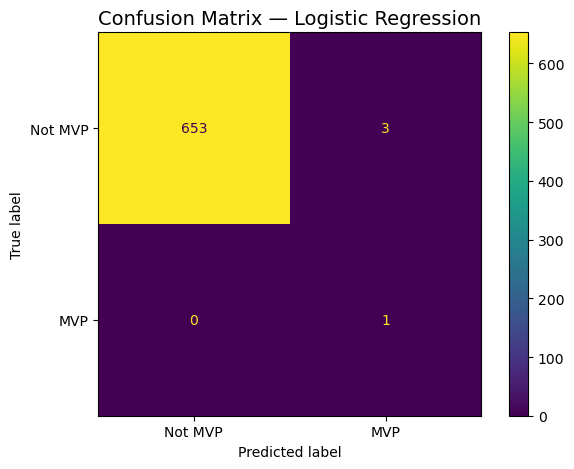

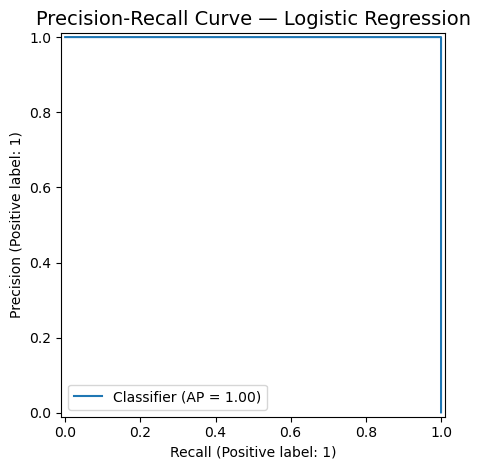

In [77]:
# Step 4 — Normalized Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not MVP", "MVP"])
disp.plot()
plt.title("Confusion Matrix — Logistic Regression", fontsize=14)
plt.tight_layout()
plt.show()

# Step 5 — Precision Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-Recall Curve — Logistic Regression", fontsize=14)
plt.tight_layout()
plt.show()

### Get Probabilities for Logistic Regression Model

In [78]:
# Get predicted probabilities
y_proba = logReg.predict_proba(X_test_scaled)[:, 1]

# Build results
test_original = test.copy().reset_index(drop=True)
test_original["MVP_prob"] = y_proba.round(4)
test_original["MVP_winner"] = y_test.values

# Merge player names back using season & index
ref_2025 = player_ref[player_ref["season"] == 2025].reset_index(drop=True)
test_results = pd.concat([ref_2025, test_original], axis=1)

# Sort and view top 15
test_results_sorted = test_results.sort_values("MVP_prob", ascending=False)
test_results_sorted[[
    "player", "team", "MVP_prob", "MVP_winner",
    "pos_PF", "pos_PG", "pos_SF", "pos_SG"
]].head(15)

,player,team,MVP_prob,MVP_winner,pos_PF,pos_PG,pos_SF,pos_SG
302,Cory Joseph,ORL,1.0000,1,False,False,False,False
204,Jazian Gortman,DAL,0.8248,0,False,True,False,False
149,Luka Dončić,LAL,0.7647,0,False,True,False,False
12,Giannis Antetokounmpo,MIL,0.5928,0,True,False,False,False
92,Wendell Carter Jr.,ORL,0.3813,0,False,True,False,False
561,Jalen Suggs,ORL,0.0855,0,True,False,False,False
512,D'Angelo Russell,BRK,0.0212,0,False,False,False,False
161,Jalen Duren,DET,0.0147,0,False,False,False,True
620,Victor Wembanyama,SAS,0.0032,0,False,False,False,True
164,Anthony Edwards,MIN,0.0028,0,False,False,False,False


### Save Test Results into file

In [79]:
prediction = test_results_sorted[[
    "player", "team", "MVP_prob", "MVP_winner",
    "pos_PF", "pos_PG", "pos_SF", "pos_SG"
]].copy()


In [80]:
prediction = prediction.rename(columns={
    'player': 'player_name',
    'MVP_prob': 'probability'
})

prediction

,player_name,team,probability,MVP_winner,pos_PF,pos_PG,pos_SF,pos_SG
302,Cory Joseph,ORL,1.0000,1,False,False,False,False
204,Jazian Gortman,DAL,0.8248,0,False,True,False,False
149,Luka Dončić,LAL,0.7647,0,False,True,False,False
12,Giannis Antetokounmpo,MIL,0.5928,0,True,False,False,False
92,Wendell Carter Jr.,ORL,0.3813,0,False,True,False,False
...,...,...,...,...,...,...,...,...
225,Tobias Harris,DET,0.0000,0,False,False,False,True
226,Isaiah Hartenstein,OKC,0.0000,0,False,False,False,True
227,Josh Hart,NYK,0.0000,0,True,False,False,False
228,Sam Hauser,BOS,0.0000,0,True,False,False,False


/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_19096/48352617.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


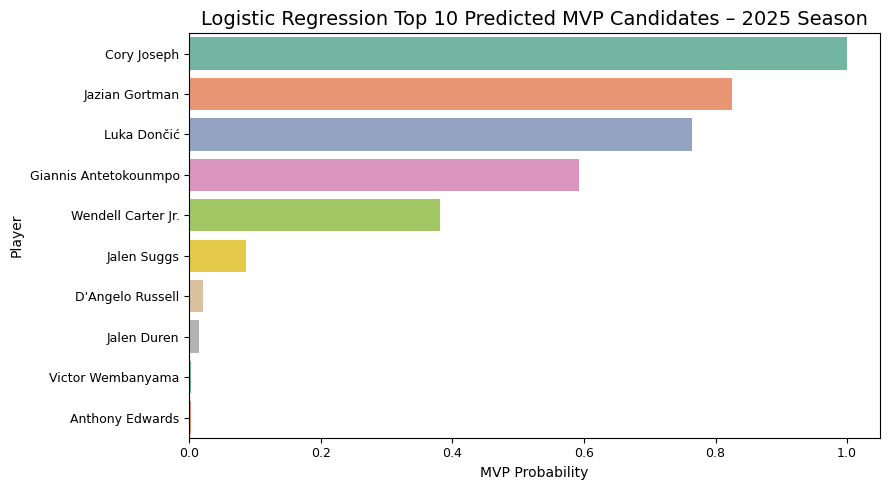

In [81]:
# Take top 10 predictions
top10 = prediction.head(10)

plt.figure(figsize=(9,5))
sns.barplot(
    data=top10,
    x="probability",
    y="player_name",
    palette="Set2"  
)
plt.tick_params(labelsize=9)
plt.title("Logistic Regression Top 10 Predicted MVP Candidates – 2025 Season", fontsize=14)
plt.xlabel("MVP Probability")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

In [82]:
# Save prediction to file

prediction_save = prediction[['player_name', 'probability']].copy()

# prediction for probability greater than 0
prediction_f = prediction_save[prediction_save['probability'] > 0]

prediction_f.to_csv('predictions.csv', index = False)

In [83]:
""" from tqdm import tqdm
from nba_api.stats.endpoints import leaguedashplayerstats, leaguestandingsv3

def get_team_standings(start_year=2000, end_year=2026):
    dfs = []

    for year in range(start_year, end_year + 1):
        season_str = f"{year}-{str(year+1)[-2:]}"
        print("Fetching:", season_str)

        time.sleep(3)  # <-- IMPORTANT (prevents NBA API blocking)

        try:
            data = leaguestandingsv3.LeagueStandingsV3(
                season=season_str,
                timeout=60   # extend timeout
            ).get_data_frames()[0]

            df = data[["TeamID", "TeamName", "WINS", "LOSSES", "WinPCT", "Conference", "PlayoffRank"]]
            df["season"] = season_str
            dfs.append(df)

        except Exception as e:
            print("FAILED FETCHING", season_str, "→", e)

            # fallback rescue: skip season
            continue

    return pd.concat(dfs, ignore_index=True)

team_standings = get_team_standings()

"""

' from tqdm import tqdm\nfrom nba_api.stats.endpoints import leaguedashplayerstats, leaguestandingsv3\n\ndef get_team_standings(start_year=2000, end_year=2026):\n    dfs = []\n\n    for year in range(start_year, end_year + 1):\n        season_str = f"{year}-{str(year+1)[-2:]}"\n        print("Fetching:", season_str)\n\n        time.sleep(3)  # <-- IMPORTANT (prevents NBA API blocking)\n\n        try:\n            data = leaguestandingsv3.LeagueStandingsV3(\n                season=season_str,\n                timeout=60   # extend timeout\n            ).get_data_frames()[0]\n\n            df = data[["TeamID", "TeamName", "WINS", "LOSSES", "WinPCT", "Conference", "PlayoffRank"]]\n            df["season"] = season_str\n            dfs.append(df)\n\n        except Exception as e:\n            print("FAILED FETCHING", season_str, "→", e)\n\n            # fallback rescue: skip season\n            continue\n\n    return pd.concat(dfs, ignore_index=True)\n\nteam_standings = get_team_standings(

In [84]:
#team_standings.to_csv('TS_data.csv', index = False)

### Introduce Random Forest

In [85]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
RF = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Fit using SMOTE resampled data
RF.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(min_samples_leaf=2, min_samples_split=5,
                       n_estimators=500, random_state=42)

### Evaluate on validation set

In [86]:

tscv = TimeSeriesSplit(n_splits=10)
rf_cv_scores = []

for train_index, val_index in tscv.split(X_train_scaled):
    X_tr, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
    y_tr, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Handle small minority class folds
    n_minority = sum(y_tr == 1)
    if n_minority < 2:
        print(f"Skipping fold — only {n_minority} MVP winner(s) in training fold")
        continue

    # Apply SMOTE inside fold
    k = min(5, n_minority - 1)
    smote = SMOTE(random_state=42, k_neighbors=k)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Train Random Forest
    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
    model.fit(X_tr_resampled, y_tr_resampled)

    # Evaluate with F1
    preds = model.predict(X_val_fold)
    rf_cv_scores.append(f1_score(y_val_fold, preds, zero_division=0))

# Confirm scores saved
print("RF CV scores saved:", rf_cv_scores)
print(f"Number of folds completed: {len(rf_cv_scores)}")

# Build results DataFrame
tscv_df = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(rf_cv_scores))],
    "F1 Score": rf_cv_scores
})

# Append summary rows
summary_df = pd.DataFrame({
    "Fold": ["Mean", "Std Dev"],
    "F1 Score": [np.mean(rf_cv_scores), np.std(rf_cv_scores)]
})

# Combine and display
final_results = pd.concat([tscv_df, summary_df], ignore_index=True)
final_results

RF CV scores saved: [0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 1.0, 0.6666666666666666, 0.6666666666666666, 0.0, 0.5, 0.0, 0.0]
Number of folds completed: 10


,Fold,F1 Score
0,Fold 1,0.666667
1,Fold 2,0.666667
2,Fold 3,0.666667
3,Fold 4,1.000000
4,Fold 5,0.666667
5,Fold 6,0.666667
6,Fold 7,0.000000
7,Fold 8,0.500000
8,Fold 9,0.000000
9,Fold 10,0.000000


In [87]:
# Step 1 — Predictions
y_pred_RF = RF.predict(X_test_scaled)
y_proba_RF = RF.predict_proba(X_test_scaled)[:, 1]

In [88]:
# Step 2 — Classification Report
print("Classification Report — Random Forest:")
print(classification_report(y_test, y_pred_RF, zero_division=0))

Classification Report — Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       656
           1       1.00      1.00      1.00         1

    accuracy                           1.00       657
   macro avg       1.00      1.00      1.00       657
weighted avg       1.00      1.00      1.00       657



In [89]:
# Step 3 — ROC AUC & PR AUC
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_RF):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_proba_RF):.4f}")


ROC-AUC:  1.0000
PR-AUC:   1.0000


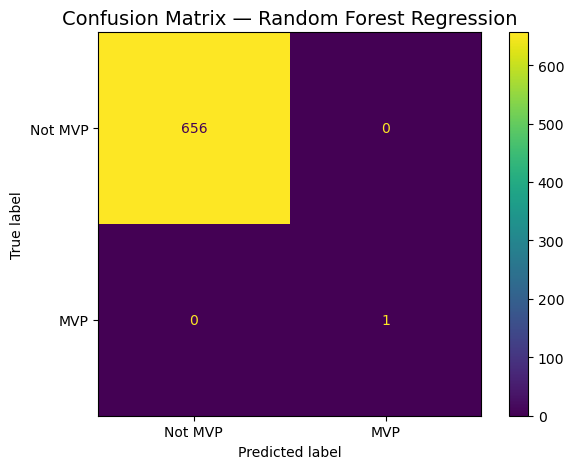

In [90]:
# Step 4 — Normalized Confusion Matrix

cm = confusion_matrix(y_test, y_pred_RF)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not MVP", "MVP"])
disp.plot()
plt.title("Confusion Matrix — Random Forest Regression", fontsize=14)
plt.tight_layout()
plt.show()

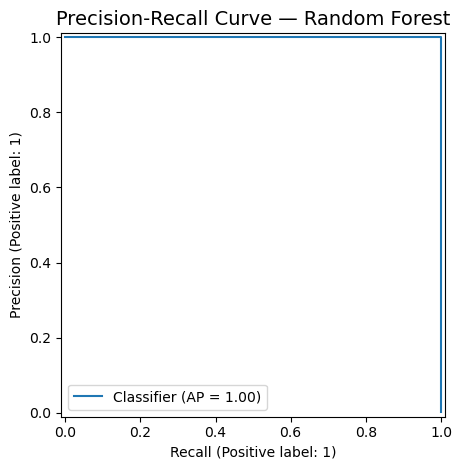

In [91]:
# Step 5 — Precision Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba_RF)
plt.title("Precision-Recall Curve — Random Forest", fontsize=14)
plt.tight_layout()
plt.show()

### Get Probabilities for Random Forest Model

In [92]:
# ---- Shared base ----
ref_2024 = player_ref[player_ref["season"] == 2024].reset_index(drop=True)
test_original = test.copy().reset_index(drop=True)
test_original["MVP_winner"] = y_test.values

# ---- Random Forest ----
y_proba_RF = RF.predict_proba(X_test_scaled)[:, 1]
test_original["RF_prob"] = y_proba_RF.round(4)

# ---- Merge player names ----
test_results = pd.concat([ref_2024, test_original], axis=1)

# ---- Sort by RF probability ----
test_results_sorted = test_results.sort_values("RF_prob", ascending=False)

# ---- View top 15 ----
test_results_sorted[[
    "player", "team", "MVP_winner", "RF_prob"
]].head(15)

,player,team,MVP_winner,RF_prob
302,Nikola Jokić,DEN,1,0.9455
149,Luka Dončić,DAL,0,0.4431
204,Shai Gilgeous-Alexander,OKC,0,0.4421
12,Giannis Antetokounmpo,MIL,0,0.2355
92,Jalen Brunson,NYK,0,0.0750
164,Joel Embiid,PHI,0,0.0621
512,Domantas Sabonis,SAC,0,0.0554
231,Tyrese Haliburton,IND,0,0.0253
135,Anthony Davis,LAL,0,0.0191
561,Jayson Tatum,BOS,0,0.0168


In [93]:
prediction = test_results_sorted[[
    "player", "team", "RF_prob", "MVP_winner",
    "pos_PF", "pos_PG", "pos_SF", "pos_SG"
]].copy()

prediction = prediction.rename(columns={
    "player": "player_name",
    "RF_prob": "probability"
})

prediction.head(15)

,player_name,team,probability,MVP_winner,pos_PF,pos_PG,pos_SF,pos_SG
302,Nikola Jokić,DEN,0.9455,1,False,False,False,False
149,Luka Dončić,DAL,0.4431,0,False,True,False,False
204,Shai Gilgeous-Alexander,OKC,0.4421,0,False,True,False,False
12,Giannis Antetokounmpo,MIL,0.2355,0,True,False,False,False
92,Jalen Brunson,NYK,0.0750,0,False,True,False,False
164,Joel Embiid,PHI,0.0621,0,False,False,False,False
512,Domantas Sabonis,SAC,0.0554,0,False,False,False,False
231,Tyrese Haliburton,IND,0.0253,0,False,True,False,False
135,Anthony Davis,LAL,0.0191,0,False,False,False,False
561,Jayson Tatum,BOS,0.0168,0,True,False,False,False


/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_19096/3110634624.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


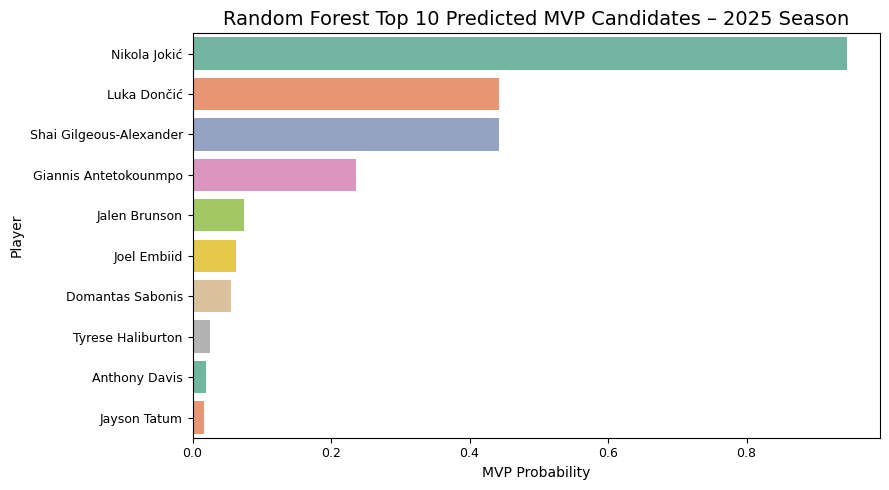

In [94]:
# Take top 10 predictions
top10 = prediction.head(10)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=top10,
    x="probability",
    y="player_name",
    palette="Set2"
)
plt.tick_params(labelsize=9)
plt.title("Random Forest Top 10 Predicted MVP Candidates – 2025 Season", fontsize=14)
plt.xlabel("MVP Probability")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

In [95]:
# Save prediction to file

prediction_RF_save = prediction[['player_name', 'probability']].copy()

# prediction for probability greater than 0
prediction_RF_f = prediction_RF_save[prediction_RF_save['probability'] > 0]

prediction_RF_f.to_csv('predictions.csv', float_format="%.4f", index = False)

### Feature Importance

          feature  importance      std
               ws    0.500000 0.000000
             obpm    0.433333 0.200000
            ws_48    0.433333 0.200000
      ast_percent    0.366667 0.266667
      tov_percent    0.150000 0.292973
team_playoff_rank    0.100000 0.270801
              bpm    0.000000 0.000000
             dbpm    0.000000 0.000000
             vorp    0.000000 0.000000
        team_wins    0.000000 0.000000


/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_19096/3631386234.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


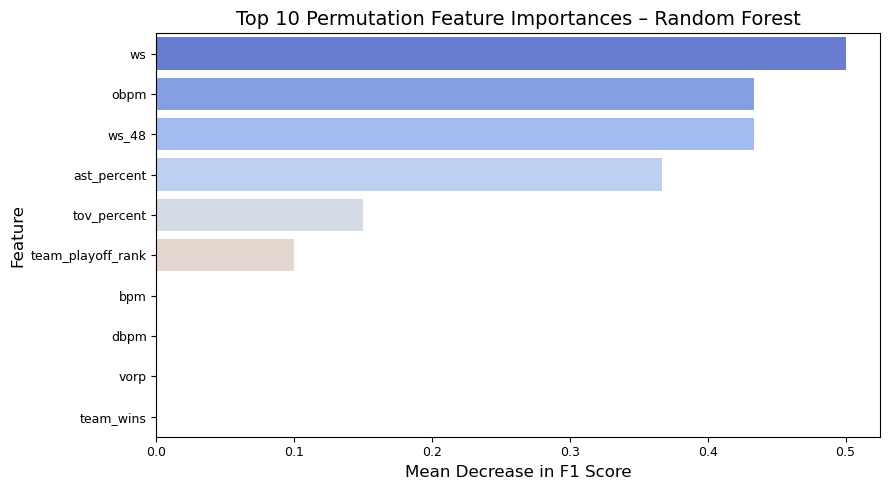

In [96]:
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import seaborn as sns

# Compute Permutation Importance
perm_result = permutation_importance(
    RF,
    X_val_scaled,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

# Build DataFrame
FI = pd.DataFrame({
    "feature": X_train.columns.tolist(),
    "importance": perm_result.importances_mean,
    "std": perm_result.importances_std
}).sort_values("importance", ascending=False)

# Display top 10
print(FI.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(9, 5))
sns.barplot(
    data=FI.head(10),
    x="importance",
    y="feature",
    palette="coolwarm"
)
plt.tick_params(labelsize=9)
plt.title("Top 10 Permutation Feature Importances – Random Forest", fontsize=14)
plt.xlabel("Mean Decrease in F1 Score", fontsize = 12)
plt.ylabel("Feature", fontsize = 12)
plt.tight_layout()
plt.show()

### Introduce XGBoost Model

In [97]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for imbalance
# Formula: number of negative samples / number of positive samples
scale = int(np.bincount(y_train_resampled)[0] / np.bincount(y_train_resampled)[1])

# Train XGBoost
XGB = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric="aucpr",      # PR-AUC — best metric for imbalanced data
    early_stopping_rounds=50  # Stops if no improvement after 50 rounds
)

# Fit with validation set for early stopping
XGB.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_val_scaled, y_val)],
    verbose=100  # Print progress every 100 rounds
)

[0]	validation_0-aucpr:0.46757
[91]	validation_0-aucpr:0.71232


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [98]:

tscv = TimeSeriesSplit(n_splits=10)
xgb_cv_scores = []

for train_index, val_index in tscv.split(X_train_scaled):
    X_tr, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
    y_tr, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Handle small minority class folds
    n_minority = sum(y_tr == 1)
    if n_minority < 2:
        print(f"Skipping fold — only {n_minority} MVP winner(s) in training fold")
        continue

    # Apply SMOTE inside fold
    k = min(5, n_minority - 1)
    smote = SMOTE(random_state=42, k_neighbors=k)
    X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

    # Calculate scale_pos_weight for this fold
    scale = int(np.bincount(y_tr_resampled)[0] / np.bincount(y_tr_resampled)[1])

    # Train XGBoost
    model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric="aucpr",
        early_stopping_rounds=50,
        verbosity=0  # Silence output inside loop
    )
    model.fit(
        X_tr_resampled, y_tr_resampled,
        eval_set=[(X_val_fold, y_val_fold)],
        verbose=False
    )

    # Evaluate with F1
    preds = model.predict(X_val_fold)
    xgb_cv_scores.append(f1_score(y_val_fold, preds, zero_division=0))

# Build results DataFrame
tscv_df = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(xgb_cv_scores))],
    "F1 Score": xgb_cv_scores
})

# Append summary rows
summary_df = pd.DataFrame({
    "Fold": ["Mean", "Std Dev"],
    "F1 Score": [np.mean(xgb_cv_scores), np.std(xgb_cv_scores)]
})

# Combine and display
final_results = pd.concat([tscv_df, summary_df], ignore_index=True)
final_results

,Fold,F1 Score
0,Fold 1,0.571429
1,Fold 2,0.500000
2,Fold 3,0.500000
3,Fold 4,1.000000
4,Fold 5,0.666667
5,Fold 6,0.571429
6,Fold 7,0.000000
7,Fold 8,0.250000
8,Fold 9,0.500000
9,Fold 10,0.000000


Classification Report — XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       656
           1       0.33      1.00      0.50         1

    accuracy                           1.00       657
   macro avg       0.67      1.00      0.75       657
weighted avg       1.00      1.00      1.00       657

ROC-AUC:  1.0000
PR-AUC:   1.0000


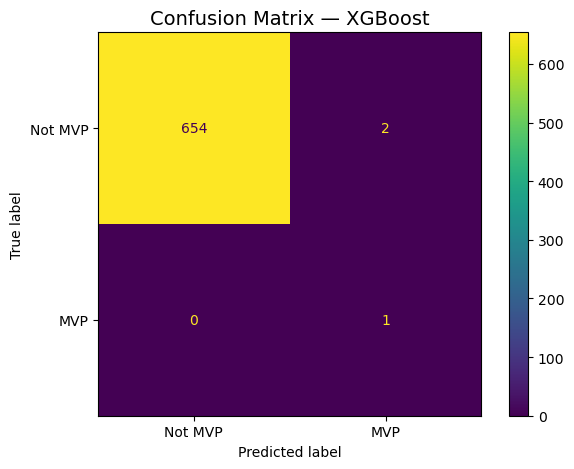

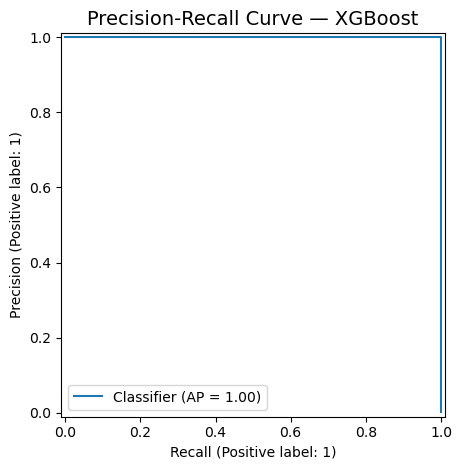

In [99]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    PrecisionRecallDisplay
)

# Step 1 — Predictions
y_pred_XGB = XGB.predict(X_test_scaled)
y_proba_XGB = XGB.predict_proba(X_test_scaled)[:, 1]

# Step 2 — Classification Report
print("Classification Report — XGBoost:")
print(classification_report(y_test, y_pred_XGB, zero_division=0))

# Step 3 — ROC AUC & PR AUC
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_XGB):.4f}")
print(f"PR-AUC:   {average_precision_score(y_test, y_proba_XGB):.4f}")

# Step 4 — Normalized Confusion Matrix
cm = confusion_matrix(y_test, y_pred_XGB)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not MVP", "MVP"])
disp.plot()
plt.title("Confusion Matrix — XGBoost", fontsize=14)
plt.tight_layout()
plt.show()

# Step 5 — Precision Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba_XGB)
plt.title("Precision-Recall Curve — XGBoost", fontsize=14)
plt.tight_layout()
plt.show()

In [100]:
# ---- Shared base ----
ref_2024 = player_ref[player_ref["season"] == 2024].reset_index(drop=True)
test_original = test.copy().reset_index(drop=True)
test_original["MVP_winner"] = y_test.values

# ---- XGBoost ----
y_proba_XGB = XGB.predict_proba(X_test_scaled)[:, 1]
test_original["XGB_prob"] = y_proba_XGB.round(4)

# ---- Merge player names ----
test_results = pd.concat([ref_2024, test_original], axis=1)

# ---- Sort by XGB probability ----
test_results_sorted = test_results.sort_values("XGB_prob", ascending=False)

# ---- View top 15 ----
test_results_sorted[[
    "player", "team", "MVP_winner", "XGB_prob"
]].head(15)

,player,team,MVP_winner,XGB_prob
302,Nikola Jokić,DEN,1,0.9377
149,Luka Dončić,DAL,0,0.8599
12,Giannis Antetokounmpo,MIL,0,0.5236
204,Shai Gilgeous-Alexander,OKC,0,0.4468
92,Jalen Brunson,NYK,0,0.1623
135,Anthony Davis,LAL,0,0.0702
209,Rudy Gobert,MIN,0,0.0702
512,Domantas Sabonis,SAC,0,0.0633
449,Cedi Osman,SAS,0,0.0603
448,Royce O'Neale,PHO,0,0.0603


In [101]:
prediction = test_results_sorted[[
    "player", "team", "XGB_prob", "MVP_winner",
    "pos_PF", "pos_PG", "pos_SF", "pos_SG"
]].copy()

prediction = prediction.rename(columns={
    "player": "player_name",
    "XGB_prob": "probability"
})

prediction.head(15)

,player_name,team,probability,MVP_winner,pos_PF,pos_PG,pos_SF,pos_SG
302,Nikola Jokić,DEN,0.9377,1,False,False,False,False
149,Luka Dončić,DAL,0.8599,0,False,True,False,False
12,Giannis Antetokounmpo,MIL,0.5236,0,True,False,False,False
204,Shai Gilgeous-Alexander,OKC,0.4468,0,False,True,False,False
92,Jalen Brunson,NYK,0.1623,0,False,True,False,False
135,Anthony Davis,LAL,0.0702,0,False,False,False,False
209,Rudy Gobert,MIN,0.0702,0,False,False,False,False
512,Domantas Sabonis,SAC,0.0633,0,False,False,False,False
449,Cedi Osman,SAS,0.0603,0,False,False,True,False
448,Royce O'Neale,PHO,0.0603,0,False,False,True,False


/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_19096/3062597994.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


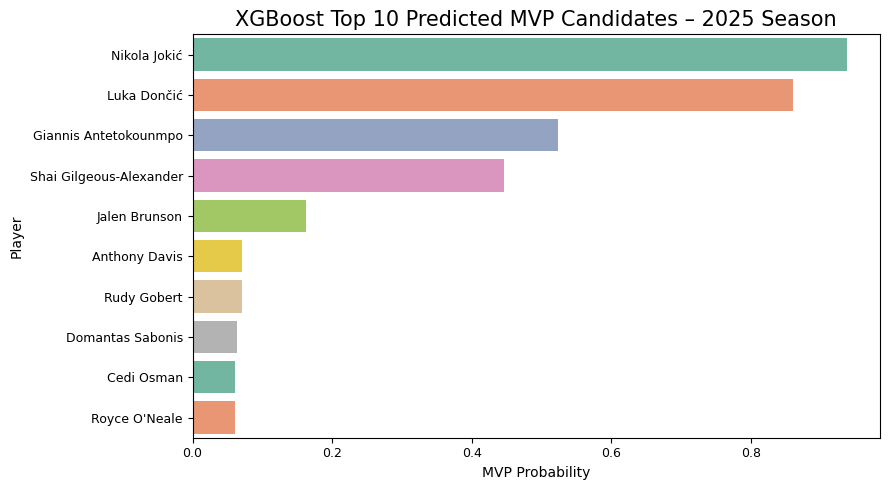

In [102]:
# Take top 10 predictions
top10 = prediction.head(10)
plt.figure(figsize=(9, 5))
sns.barplot(
    data=top10,
    x="probability",
    y="player_name",
    palette="Set2"
)
plt.tick_params(labelsize=9)
plt.title("XGBoost Top 10 Predicted MVP Candidates – 2025 Season", fontsize=15)
plt.xlabel("MVP Probability")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

### Model Comparison

In [103]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import pandas as pd
import numpy as np

# ---- Define models and their CV scores ----
models = {
    "Logistic Regression": {
        "model": logReg,
        "cv_scores": lg_cv_scores
    },
    "Random Forest": {
        "model": RF,
        "cv_scores": rf_cv_scores  # Now safely uses your saved RF scores
    },
    "XGBoost": {
        "model": XGB,
        "cv_scores": xgb_cv_scores
    }
}

# ---- Auto extract all metrics ----
results = []
for name, info in models.items():
    model = info["model"]
    cv = info["cv_scores"]

    # Probabilities
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "CV Mean F1": round(np.mean(cv), 4),
        "CV Std Dev": round(np.std(cv), 4),
        "Test F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4),
        "PR-AUC": round(average_precision_score(y_test, y_proba), 4)
    })

# ---- Build comparison DataFrame ----
comparison = pd.DataFrame(results)
comparison

,Model,CV Mean F1,CV Std Dev,Test F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.4267,0.2280,0.4,1.0,1.0
1,Random Forest,0.4833,0.3371,1.0,1.0,1.0
2,XGBoost,0.4560,0.2883,0.5,1.0,1.0


### SHAP Plot

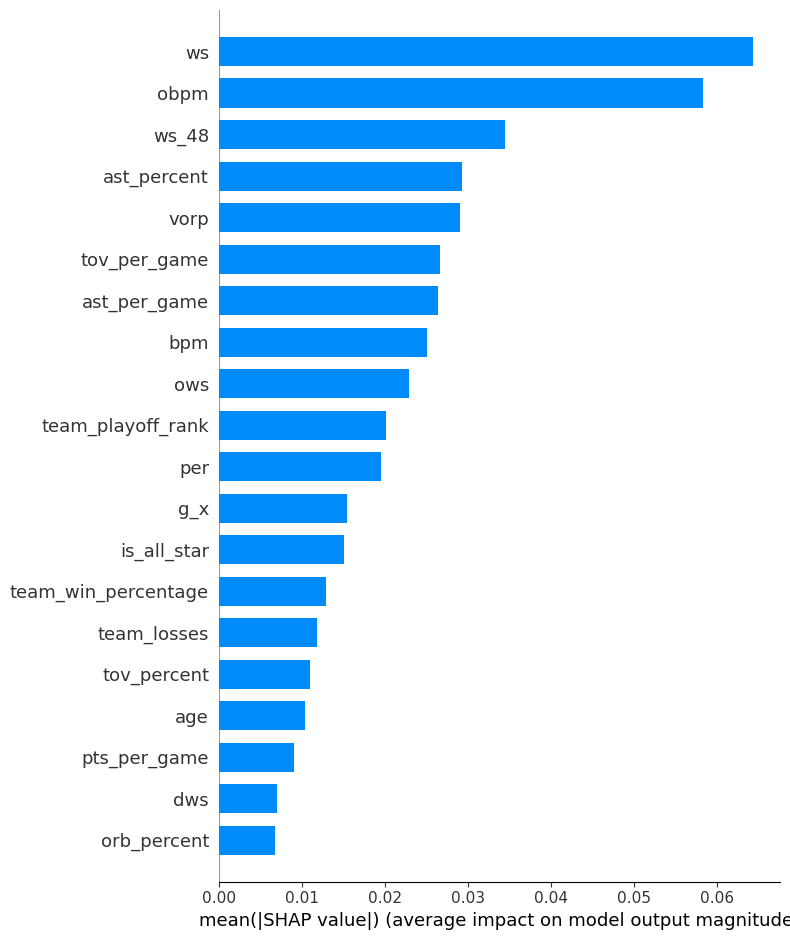

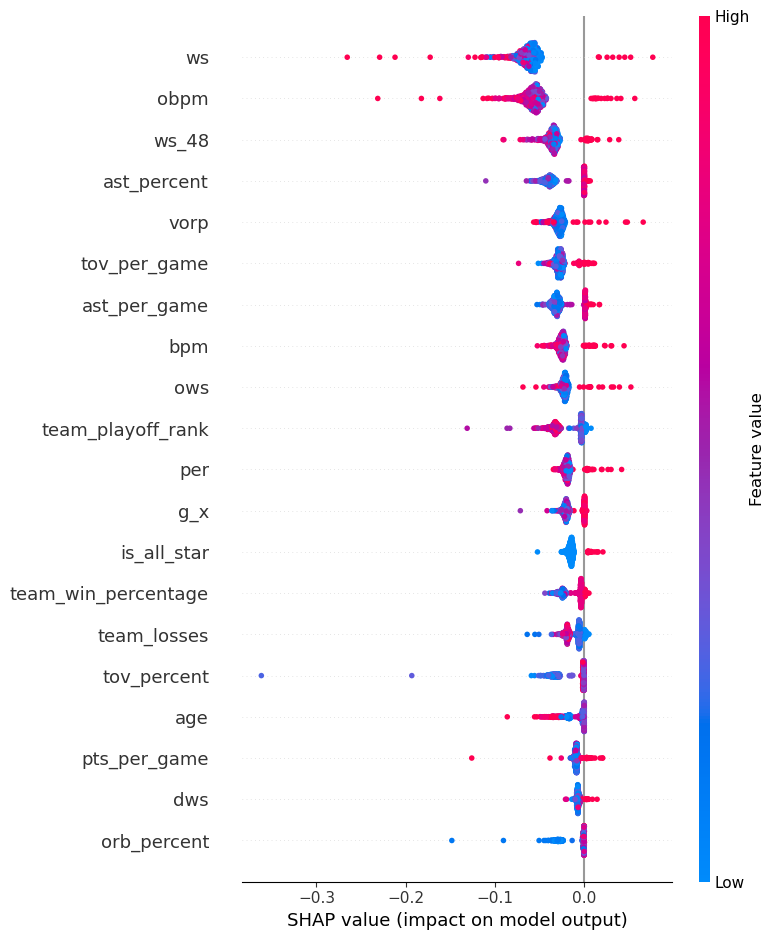

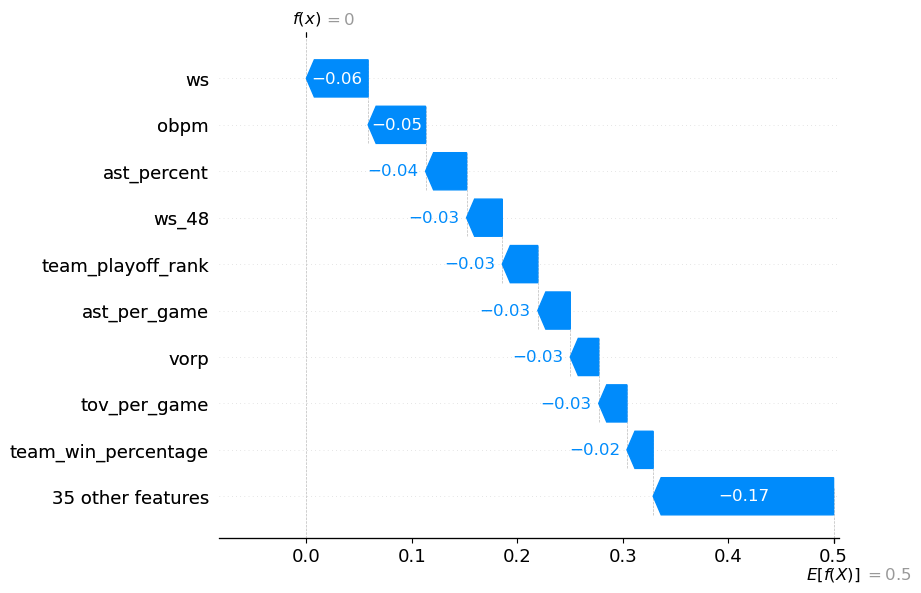

In [104]:
import shap
import matplotlib.pyplot as plt

# ---- Initialize SHAP Explainer with Random Forest ----
explainer = shap.TreeExplainer(RF)

# ---- Calculate SHAP values on test set ----
shap_values = explainer.shap_values(X_test_scaled)

# ---- Plot 1: Summary Plot (Bar) ----
plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],  # Class 1 = MVP
    X_test_scaled,
    feature_names=X_train.columns.tolist(),
    plot_type="bar",
    show=True
)


# ---- Plot 2: Beeswarm Plot ----
plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],  # Class 1 = MVP
    X_test_scaled,
    feature_names=X_train.columns.tolist(),
    show=True
)


# ---- Plot 3: Waterfall for Top MVP Candidate ----
top_player_index = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[top_player_index, :, 1],
        base_values=explainer.expected_value[1],
        feature_names=X_train.columns.tolist()
    )
)
